Lade ENA-Metadaten...
ENA-Daten: 678 Samples

Verarbeite Stadt: Copenhagen
Top 10 am schnellsten verändernde Viren in Copenhagen:
name
Tobamovirus       20.060000
Kinglevirus        8.966364
Purivirus          6.170000
Pettyvirus         4.798182
Tunggulvirus       4.211818
Shizishanvirus     4.129091
Burzaovirus        3.292727
Junduvirus         2.322727
Nicoomyvirus       1.794545
Kirikabuvirus      1.697273
dtype: float64




<Figure size 1000x400 with 0 Axes>

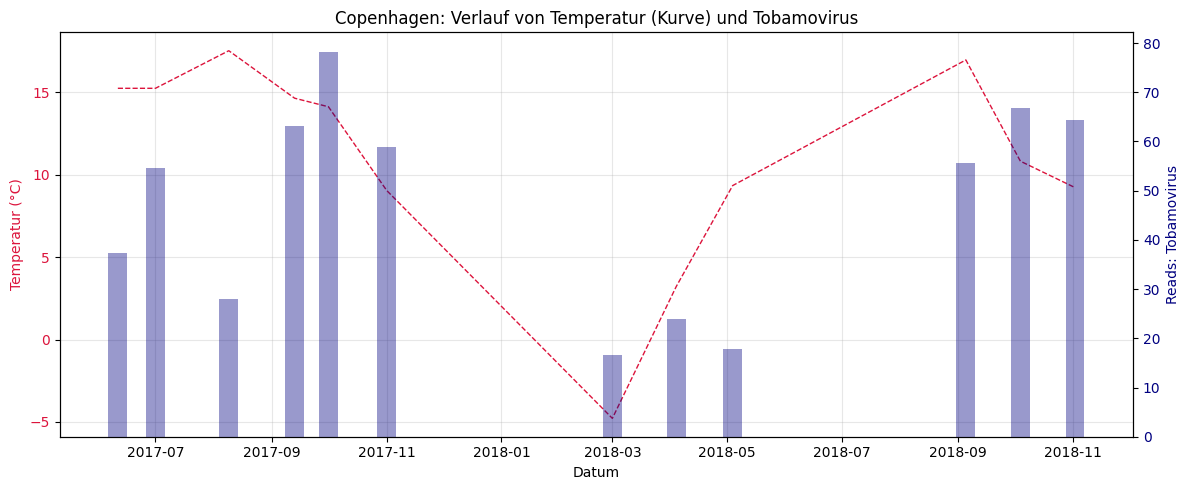

Verarbeite Stadt: Guangzhou
Top 10 am schnellsten verändernde Viren in Guangzhou:
name
Tobamovirus        11.090769
Gemykibivirus       2.740769
Kagunavirus         1.721538
Gammacarmovirus     1.597692
Efbeekayvirus       1.208462
Betabaculovirus     1.041538
Burrovirus          0.832308
Salvovirus          0.751538
Kehishuvirus        0.720769
Potexvirus          0.660000
dtype: float64




<Figure size 1000x400 with 0 Axes>

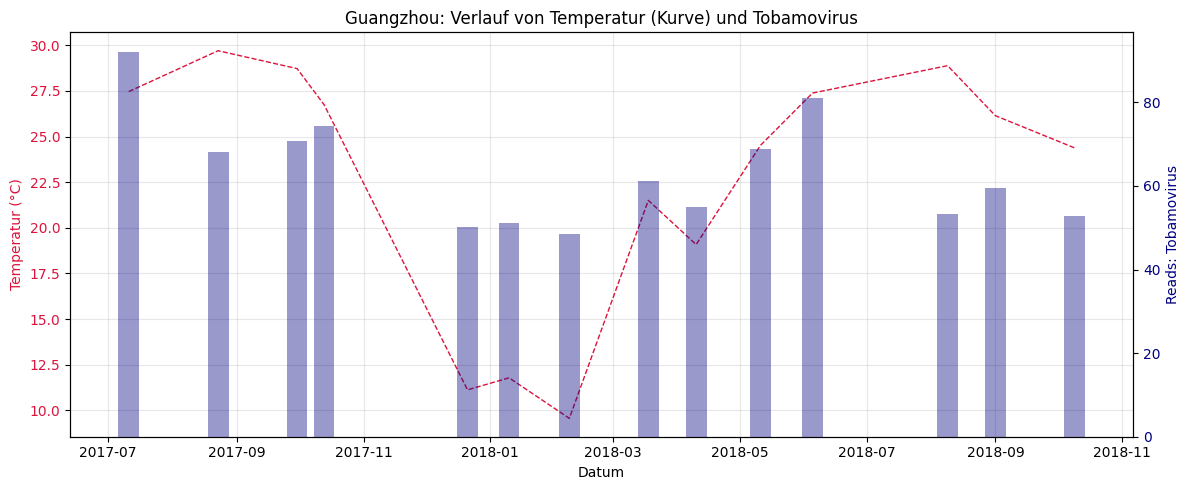

Verarbeite Stadt: Kuala Lumpur
Top 10 am schnellsten verändernde Viren in Kuala Lumpur:
name
Tobamovirus      19.707143
Burzaovirus       7.561429
Carjivirus        3.062143
Potexvirus        3.056429
Kinglevirus       2.092143
Webervirus        1.795714
Aurodevirus       1.619286
Afonbuvirus       1.426429
Muminvirus        1.257143
Efbeekayvirus     1.065714
dtype: float64




<Figure size 1000x400 with 0 Axes>

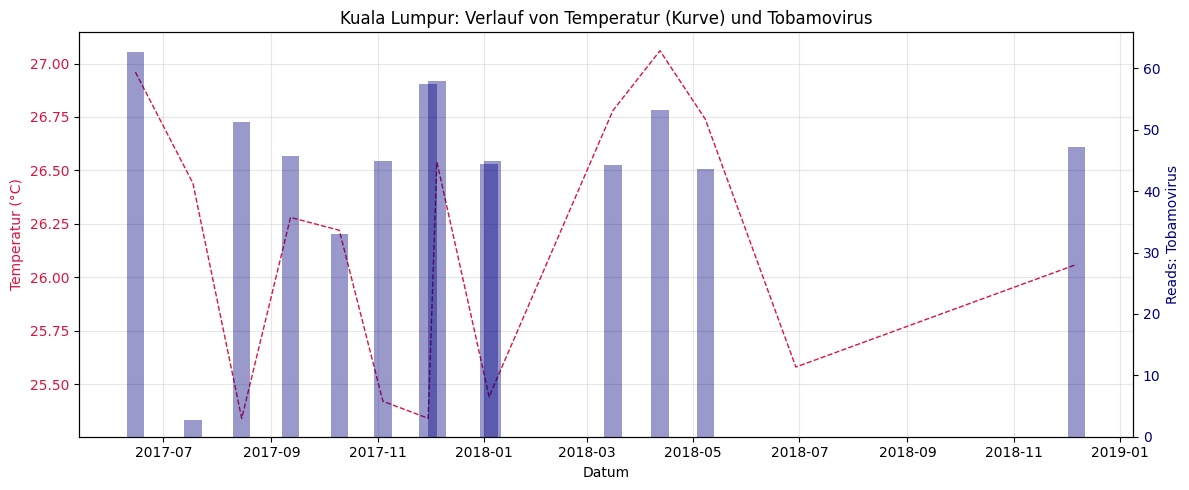

Verarbeite Stadt: Melbourne
Top 10 am schnellsten verändernde Viren in Melbourne:
name
Tobamovirus       9.695000
Longwangvirus     5.584286
Kirikabuvirus     3.811429
Carjivirus        3.187857
Nehpavirus        2.742143
Tunggulvirus      2.737857
Alphanodavirus    2.597143
Ceetrepovirus     2.108571
Burzaovirus       2.030714
Junduvirus        1.977857
dtype: float64




<Figure size 1000x400 with 0 Axes>

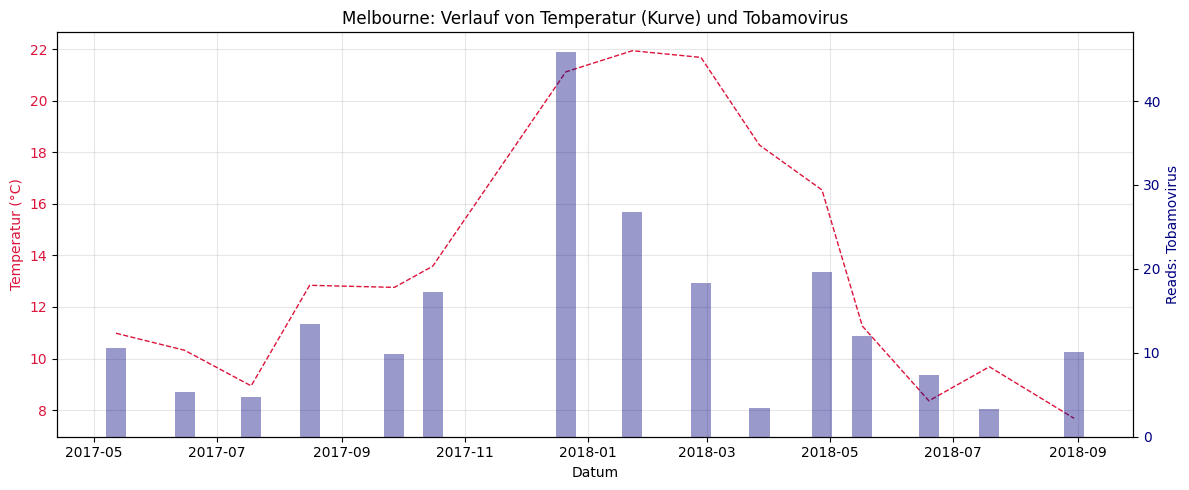

Verarbeite Stadt: Quito
Top 10 am schnellsten verändernde Viren in Quito:
name
Tobamovirus          9.765000
Tombusvirus          6.600714
Burzaovirus          4.609286
Gihfavirus           4.162143
Cripavirus           2.758571
Gemykibivirus        2.235000
Gammacarmovirus      1.906429
Gemycircularvirus    1.862857
Junduvirus           1.208571
Farahnazvirus        1.184286
dtype: float64




<Figure size 1000x400 with 0 Axes>

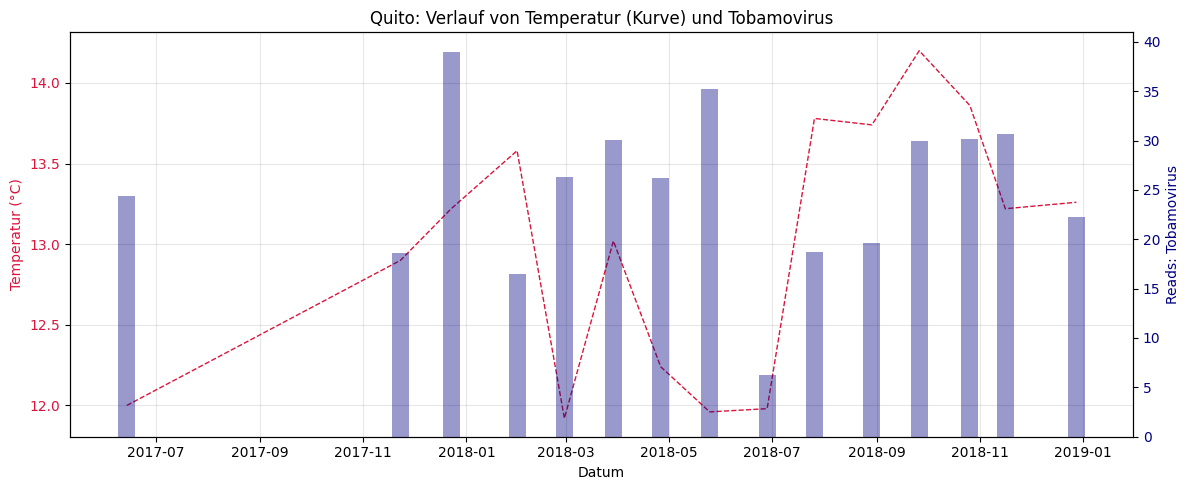

Verarbeite Stadt: Regina
Top 10 am schnellsten verändernde Viren in Regina:
name
Tobamovirus        17.144286
Carjivirus          3.317143
Burzaovirus         2.154286
Rauchvirus          1.847857
Sholavirus          1.305714
Kingevirus          0.749286
Afonbuvirus         0.732857
Jahgtovirus         0.709286
Gammacarmovirus     0.708571
Hohrdovirus         0.654286
dtype: float64




<Figure size 1000x400 with 0 Axes>

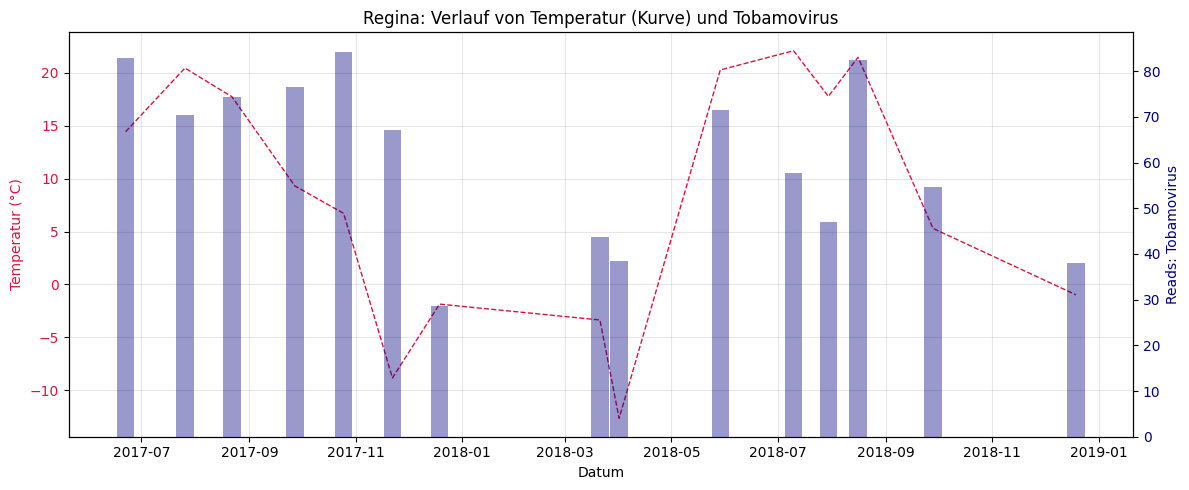

Verarbeite Stadt: Seattle
Top 10 am schnellsten verändernde Viren in Seattle:
name
Tobamovirus         14.980714
Tunggulvirus        13.840714
Kirikabuvirus       10.487143
Hennigervirus        7.672857
Gihfavirus           6.576429
Burzaovirus          5.683571
Carjivirus           4.577143
Miecznikowavirus     3.002143
Purivirus            2.842143
Dismasvirus          2.614286
dtype: float64




<Figure size 1000x400 with 0 Axes>

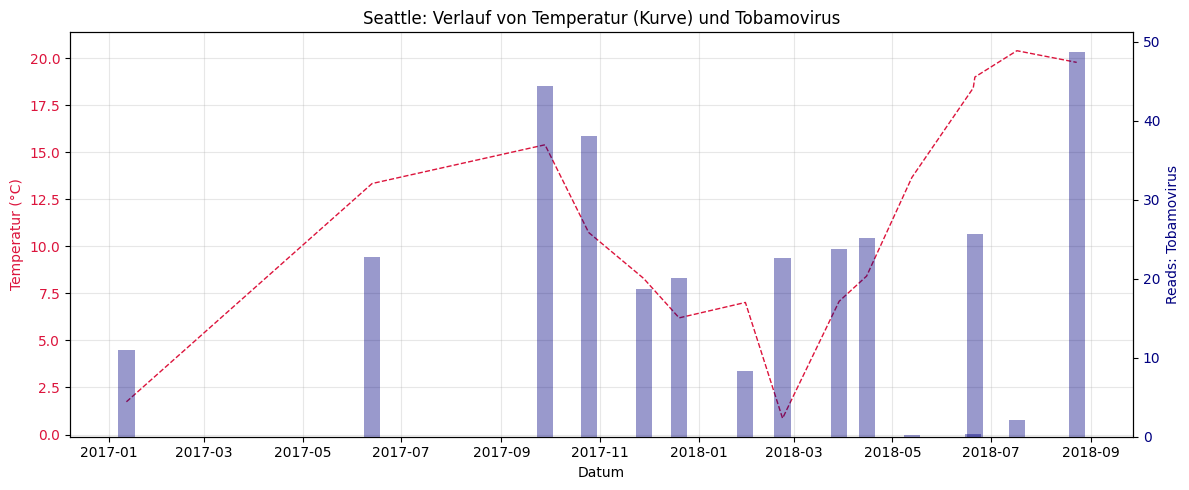

Verarbeite Stadt: Yaounde
Top 10 am schnellsten verändernde Viren in Yaounde:
name
Burzaovirus           17.373333
Cyclovirus            11.393333
Tobamovirus            9.735333
Ghunavirus             6.982667
Przondovirus           4.784000
Mastadenovirus         3.952000
Junduvirus             3.190000
Kagunavirus            2.256667
Gemykibivirus          1.970667
Pefuambidensovirus     1.960000
dtype: float64




<Figure size 1000x400 with 0 Axes>

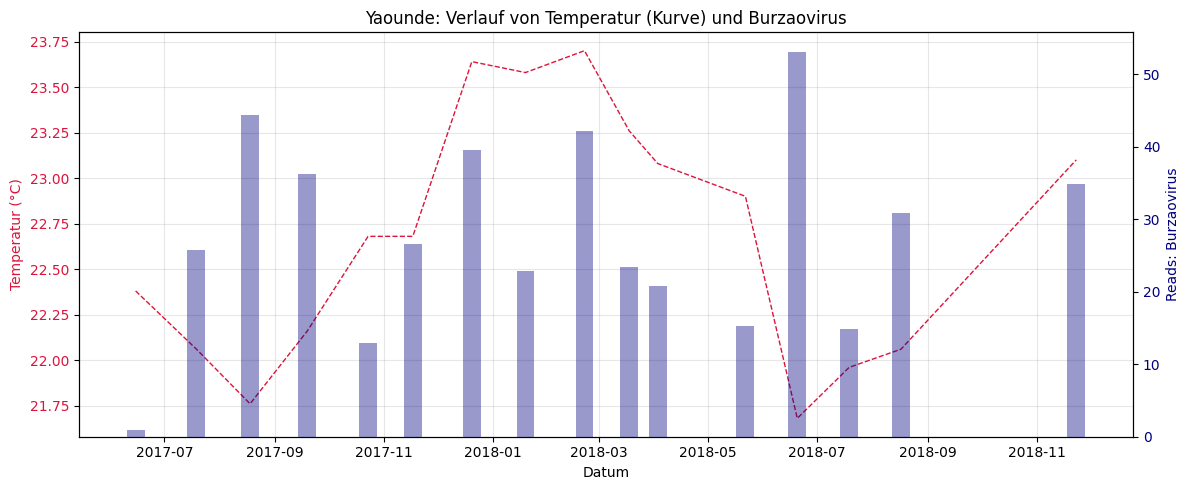

Alle Städte berechnet!


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')

# Dateipfade pro Stadt
cities = {
    'Copenhagen':   ('Copenhagen_merged_reads.csv',  'Copenhagen_weather.csv'),
    'Guangzhou':    ('Guangzhou_merged_reads.csv',   'Guangzhou_weather.csv'),
    'Kuala Lumpur': ('KualaLumpur_merged_reads.csv', 'KualaLumpur_weather.csv'),
    'Melbourne':    ('Melbourne_merged_reads.csv',   'Melbourne_weather.csv'),
    'Quito':        ('Quito_merged_reads.csv',       'Quito_weather.csv'),
    'Regina':       ('Regina_merged_reads.csv',      'Regina_weather.csv'),
    'Seattle':      ('Seattle_merged_reads.csv',     'Seattle_weather.csv'),
    'Yaounde':      ('Yaounde_merged_reads.csv',     'Yaounde_weather.csv'),
}


wetter_spalten = {
    'temperature_2m_mean (°C)':      'Temp',
    'rain_sum (mm)':                 'Regen',
    'relative_humidity_2m_mean (%)': 'Luftfeuchtigkeit',
}

print("Lade ENA-Metadaten...")
ena_data = pd.read_csv('ena_data.tsv', sep='\t')
print(f"ENA-Daten: {len(ena_data)} Samples\n")

# Ergebnisse für jede Stadt speichern
ergebnisse_pro_stadt = {}

for city, (virus_file, weather_file) in cities.items():
    print(f"Verarbeite Stadt: {city}")

    # Virus-Tabelle laden (Zeilen = Samples, Spalten = Virusarten)
    virus_df = pd.read_csv(virus_file, index_col=0).fillna(0).T
    virus_df.columns = virus_df.columns.str.strip()
    virus_df = virus_df.drop('taxid', errors='ignore')

    # Alle Proben IDs einer Stadt
    sample_ids = virus_df.index.tolist()

    # Datum ENA-Metadaten holen
    ena_city = (
        ena_data[ena_data['run_accession'].isin(sample_ids)]
        [['run_accession', 'collection_date']]
        .copy()
        .rename(columns={'run_accession': 'Sample', 'collection_date': 'Date'})
    )
    ena_city['Date'] = pd.to_datetime(ena_city['Date'])

    # Data Frame mit Samples und Datum
    data = ena_city.copy()

    # Wetterdaten laden
    weather_df = pd.read_csv(weather_file)
    weather_df['time'] = pd.to_datetime(weather_df['time'])

    # Mittelwert plus 4 Tage vor Sammeldatum
    for csv_spalte, col_name in wetter_spalten.items():
        data[col_name] = np.nan
        for i, row in data.iterrows():
            start = row['Date'] - pd.Timedelta(days=4)
            maske = (weather_df['time'] >= start) & (weather_df['time'] <= row['Date'])
            data.at[i, col_name] = weather_df.loc[maske, csv_spalte].mean()

    # Zeilen bereinigen wo Wetterdaten fehlen
    data_clean = data.dropna(subset=list(wetter_spalten.values()))
    data_clean = data_clean.sort_values('Date')

    # Nur vorhandene Samples behalten
    virus_df_clean = virus_df.loc[data_clean['Sample']]

    # Ausbreitungsgeschwindigkeit pro Stadt berechnen
    virus_cols = [col for col in virus_df_clean.columns if col not in ['Date', 'Sample', 'taxid']]
    virus_timeline = virus_df_clean[virus_cols].copy()
    virus_timeline.index = data_clean['Date']

    # Falls eine Stadt nur eine Probe hat
    if len(virus_timeline) < 2:
        print(f"-> {city} hat insgesamt nur {len(virus_timeline)} Probe(n). Keine zeitliche Differenz berechenbar.")
        print("-" * 30 + "\n")
        continue

    # Ausbreitungsgeschwindigkeit
    # Absolute Änderung von Monat zu Monat
    speed = virus_timeline.diff().abs()

    # Top 10 Viren mit der schnellsten Änderung im Schnitt
    top_fastest_virus = speed.mean(skipna=True).fillna(0).sort_values(ascending=False)
    top_fastest_virus = top_fastest_virus[top_fastest_virus > 0].head(10)

    print(f"Top 10 am schnellsten verändernde Viren in {city}:")
    print(top_fastest_virus.head(10))
    print("\n")

    # Ergebnisse im Dictionary speichern für die Plots
    ergebnisse_pro_stadt[city] = {
        'weather_and_dates': data_clean,
        'virus_reads': virus_df_clean,
        'speed': speed,
        'top_fastest': top_fastest_virus
    }
    
    # Verlauf über 2 Jahre 
    if len(top_fastest_virus) > 0:
        best_virus = top_fastest_virus.index[0] #dynamischste Virus

        plt.figure(figsize=(10, 4))
        fig, ax1 = plt.subplots(figsize=(12, 5))

        # Wettervariable: rote linie
        color_wetter = 'crimson'
        ax1.set_xlabel('Datum')
        ax1.set_ylabel('Temperatur (°C)', color=color_wetter)
    
        ax1.plot(data_clean['Date'], data_clean['Temp'], color=color_wetter, linewidth=1, linestyle='--', label='Temperatur')        
        ax1.tick_params(axis='y', labelcolor=color_wetter)
        ax1.grid(True, alpha=0.3)

        # Viren-Anzahl: dunkelblaue Säulen
        ax2 = ax1.twinx()
        color_virus = 'navy'
        ax2.set_ylabel(f'Reads: {best_virus}', color=color_virus)
    
        ax2.bar(data_clean['Date'], virus_df_clean[best_virus], color=color_virus, alpha=0.4, width=10, label=best_virus)
        ax2.tick_params(axis='y', labelcolor=color_virus)

        plt.title(f'{city}: Verlauf von Temperatur (Kurve) und {best_virus}')
        fig.tight_layout()
        plt.show()
        plt.close()


In [22]:
# Viren Vorhersage durch Wettervariablen
print("Statistiscshe Auswertung: Welche Viren reagieren am stärksten auf das Wetter?")

for city, info in ergebnisse_pro_stadt.items():
    df_wetter = info['weather_and_dates']
    df_virus = info['virus_reads']
    top_viren = info['top_fastest'].index
    
    print(f"\n Wetter-Einfluss & Vorhersagbarkeit für {city}")
    
    for w_col in ['Temp', 'Regen', 'Luftfeuchtigkeit']:
        zusammenhang = []
        for v_col in top_viren:
            # Pearson-Korrelation zwischen Wetter und Virusmenge
            r_val, p_val = pearsonr(df_wetter[w_col], df_virus[v_col])
            zusammenhang.append({'Virus': v_col, 'Korrelation (r)': r_val, 'Signifikanz (p)': p_val})
            
        anziehung_df = pd.DataFrame(zusammenhang).dropna()
        if not anziehung_df.empty:
            # Sortieren nach der Stärke des Effekts (Absolutwert von r)
            anziehung_df = anziehung_df.sort_values(by='Korrelation (r)', key=abs, ascending=False).head(3)
            print(f"\n Top-Viren reagierend auf {w_col}:")
            print(anziehung_df.to_string(index=False))

Statistiscshe Auswertung: Welche Viren reagieren am stärksten auf das Wetter?

 Wetter-Einfluss & Vorhersagbarkeit für Copenhagen

 Top-Viren reagierend auf Temp:
       Virus  Korrelation (r)  Signifikanz (p)
  Pettyvirus        -0.784801         0.002500
 Tobamovirus         0.481622         0.112874
Tunggulvirus         0.398729         0.199178

 Top-Viren reagierend auf Regen:
        Virus  Korrelation (r)  Signifikanz (p)
Kirikabuvirus         0.588377         0.044174
 Tunggulvirus         0.493903         0.102679
  Burzaovirus        -0.492285         0.103986

 Top-Viren reagierend auf Luftfeuchtigkeit:
      Virus  Korrelation (r)  Signifikanz (p)
 Pettyvirus        -0.721022         0.008142
Tobamovirus         0.480924         0.113474
Kinglevirus        -0.394712         0.204162

 Wetter-Einfluss & Vorhersagbarkeit für Guangzhou

 Top-Viren reagierend auf Temp:
          Virus  Korrelation (r)  Signifikanz (p)
  Efbeekayvirus        -0.802567         0.000551
Gammacarmo